## import

In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')

In [20]:
from ult import *
from irc_gym.irc.model import FuncBeliefModel
from stable_baselines3 import PPO
from auditoryforage.AF_env import AuditoryForagingReward2 as AFR2


In [21]:
def compute_autocorrelation(sequence):
    autocorr = np.correlate(sequence, sequence, mode='full')
    autocorr /= np.max(autocorr)
    return autocorr

## train

In [22]:
modelname = 'test'
# training hyper params
epoch_size = 15000
n_epoch = 120
n_seed = 1
modeli = 0


env_param = [0, 1000, 0.087213, 0.25, -30, 0, 0, 0]
seed=0
thismodel = f'seed_{seed}_{modelname}_{modeli}'
print(thismodel)

task = AFR2(spec={'agent': {'lick_cost': env_param[0],
                            'food_reward': env_param[1],
                            'attention_cost_coeff': env_param[2],
                            'attention_cost_temp': env_param[3],
                            'penalty_cost': env_param[4],
                            'iti_cost': env_param[5],
                            'time_in_game_reward': env_param[6]}})
task.food_reward_list = np.linspace(9, 999, 15)
taskbelief = FuncBeliefModel(env=task, rng=1)
model = PPO('MlpPolicy', taskbelief, verbose=0, device='cpu',
            clip_range=0.1, ent_coef=0.01, tensorboard_log=f"runs",)

task.find_reward_(0,1),task.find_reward_(0,0)


seed_0_test_0


/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


(-1.5847126606442856, 0.0)

In [23]:
modelname = 'test'
# training hyper params
epoch_size = 22222
n_epoch = 120
n_seed = 1
modeli = 0

for attcost in [-1.584712660644285]:
    for facost in [-30,]:
        # , np.array([.6,.7]),np.array([.5,.7])]:
        for p1p2 in [np.array([.5, .6])]:
            # reward list
            vmin, vmax = 10, 10000
            food_reward_list = np.linspace(vmin, vmax, 5)
            # food_reward_list=np.exp(food_reward_list)

            print('food reard list: ', [f'{a:.0f}' for a in food_reward_list])

            # other env params
            env_param = [0, None, attcost, .25, facost, 0, 0]
            seed=0
            thismodel = f'seed_{seed}_{modelname}_{modeli}'
            print(thismodel)
       
            task = AFR2(spec={'agent': {'lick_cost': env_param[0],
                                        'food_reward': env_param[1],
                                        'attention_cost_coeff': env_param[2],
                                        'attention_cost_temp': env_param[3],
                                        'penalty_cost': env_param[4],
                                        'iti_cost': env_param[5],
                                        'time_in_game_reward': env_param[6]}})
            task.food_reward_list = food_reward_list
            taskbelief = FuncBeliefModel(env=task, rng=1)
            # set p1 p2
            task.obs_certainity_possible = p1p2
            model = PPO('MlpPolicy', taskbelief, verbose=0, device='cpu',
                        clip_range=0.1, ent_coef=0.01, tensorboard_log=f"runs",)
      

task.find_reward(0,1),task.find_reward(0,0)

food reard list:  ['10', '2508', '5005', '7502', '10000']
seed_0_test_0


(-1.584712660644285, 0.0)

food reard list:  ['10', '2508', '5005', '7502', '10000']
seed_0_test_0


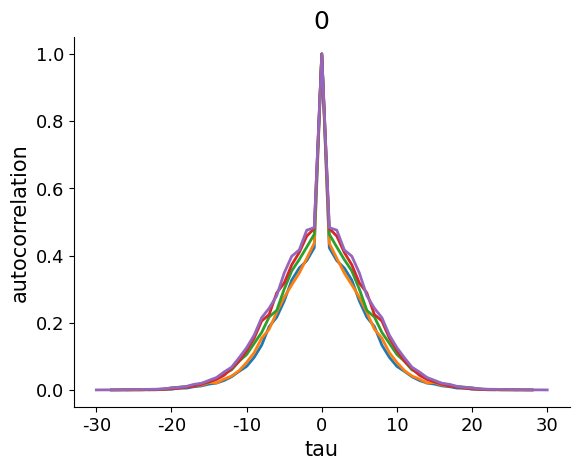

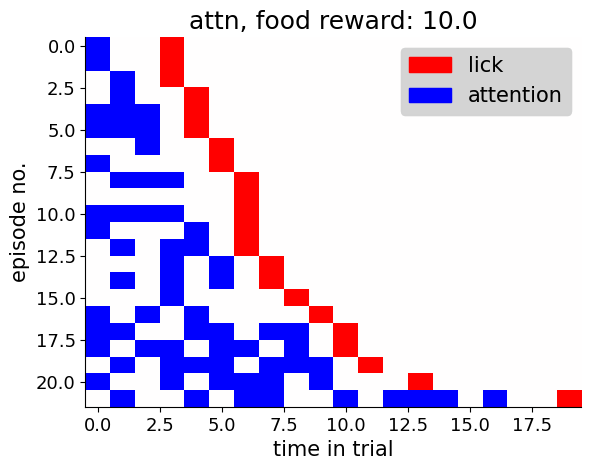

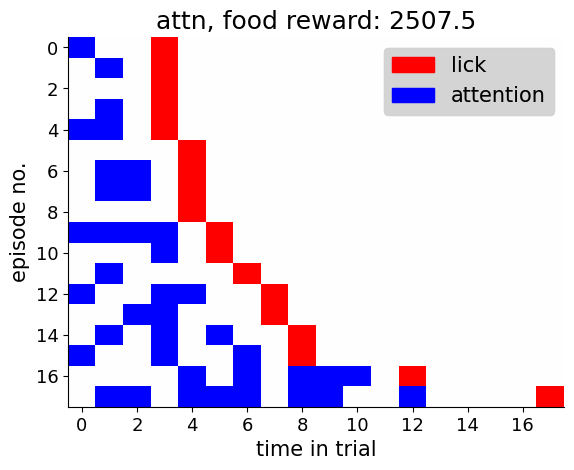

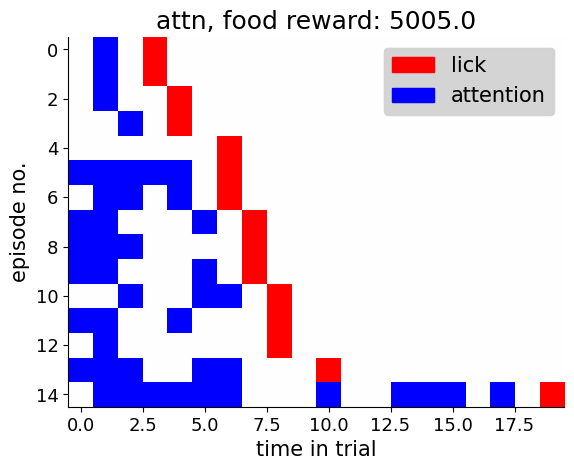

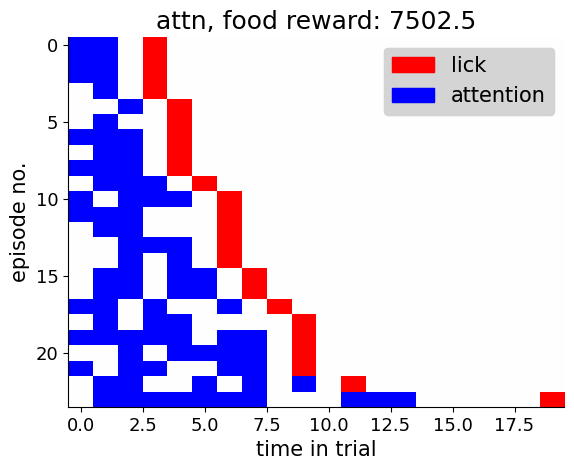

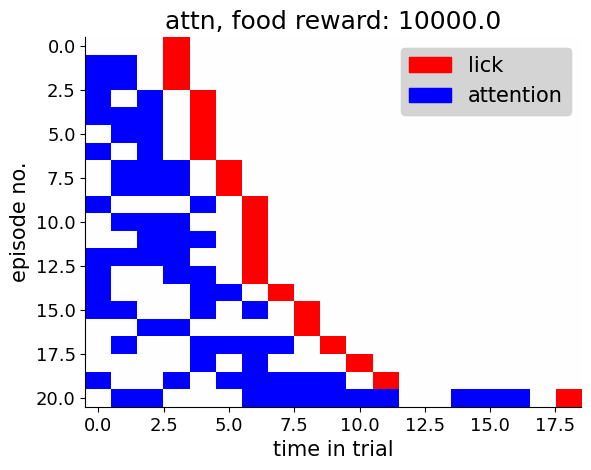

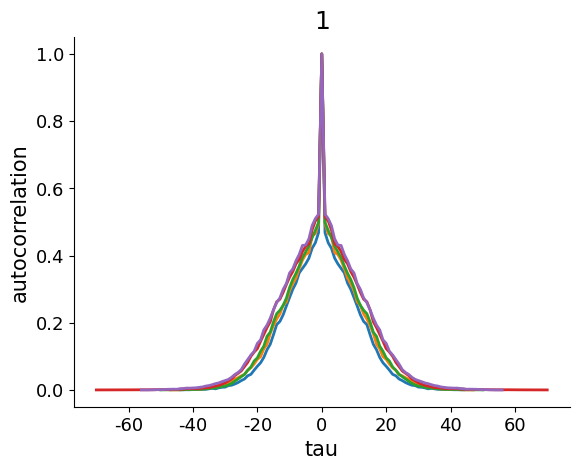

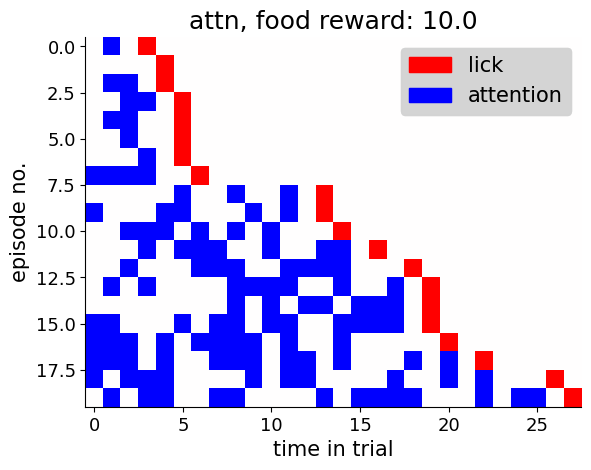

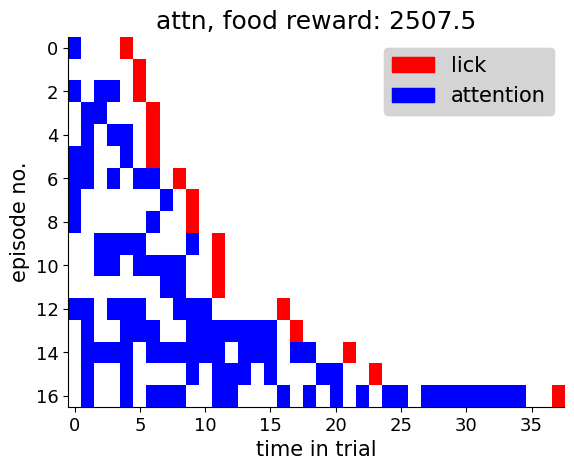

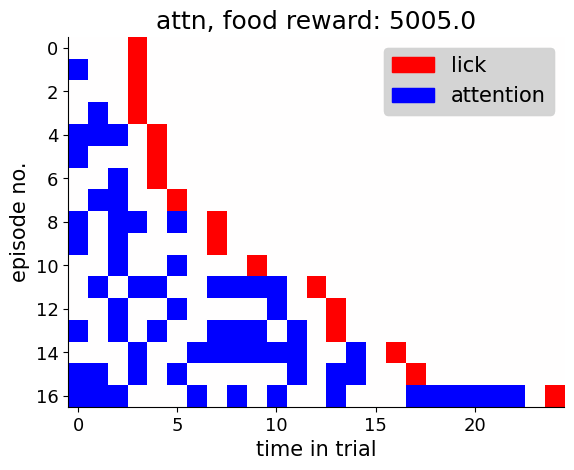

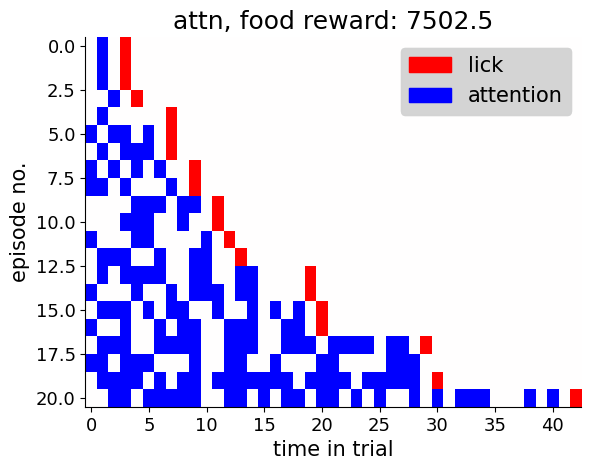

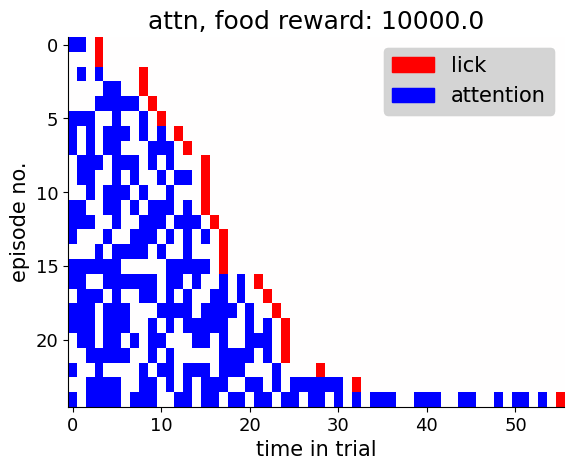

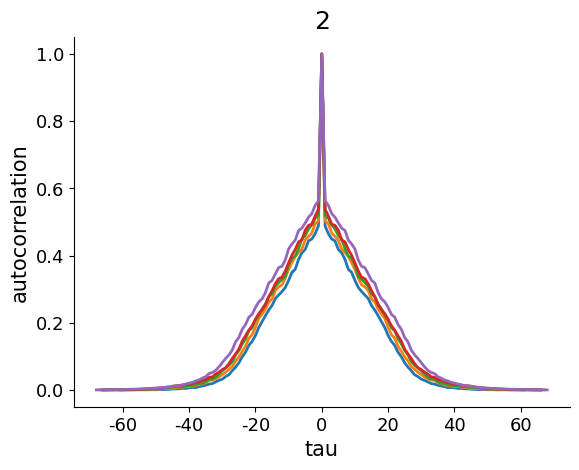

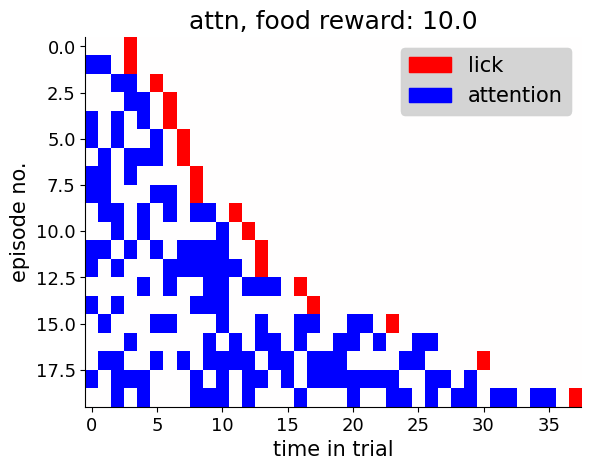

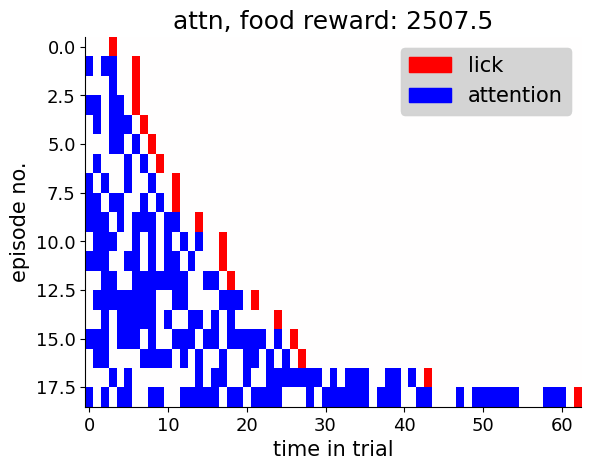

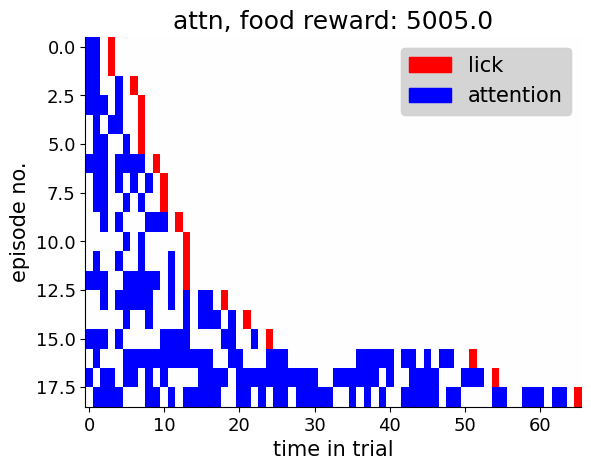

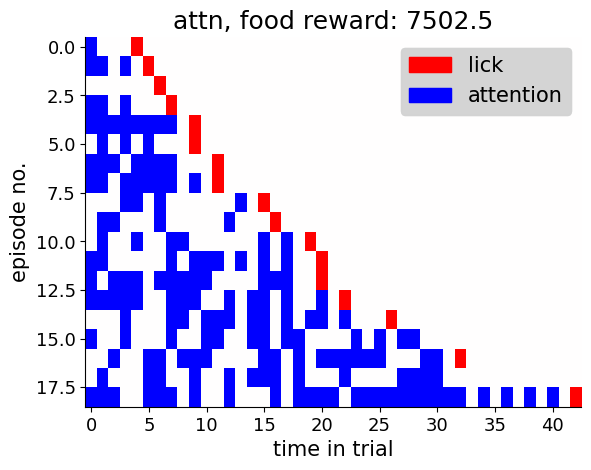

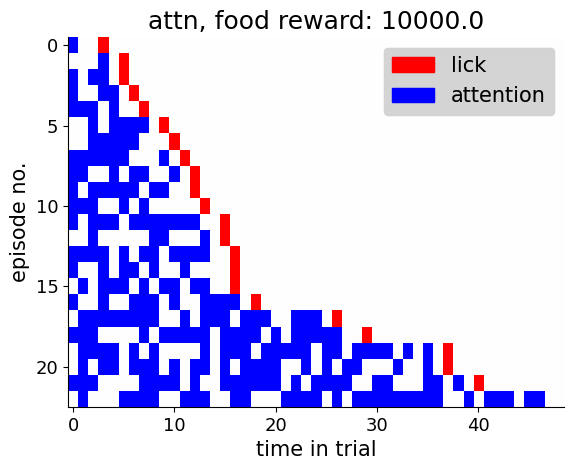

In [24]:
modelname = 'test'
# training hyper params
epoch_size = 15000
n_epoch = 120
n_seed = 1
modeli = 0

for attcost in [-1.584712660644285]:
    for facost in [-30,]:
        # , np.array([.6,.7]),np.array([.5,.7])]:
        for p1p2 in [np.array([.5, .6])]:
            # reward list
            vmin, vmax = 10, 10000
            food_reward_list = np.linspace(vmin, vmax, 5)
            # food_reward_list=np.exp(food_reward_list)

            print('food reard list: ', [f'{a:.0f}' for a in food_reward_list])

            # other env params
            env_param = [0, None, attcost, .25, facost, 0, 0]
            seed=0
            thismodel = f'seed_{seed}_{modelname}_{modeli}'
            print(thismodel)
            for seed in range(n_seed):
                # set seed
                np.random.seed(seed)
                task = AFR2(spec={'agent': {'lick_cost': env_param[0],
                                            'food_reward': env_param[1],
                                            'attention_cost_coeff': env_param[2],
                                            'attention_cost_temp': env_param[3],
                                            'penalty_cost': env_param[4],
                                            'iti_cost': env_param[5],
                                            'time_in_game_reward': env_param[6]}})
                task.food_reward_list = food_reward_list
                taskbelief = FuncBeliefModel(env=task, rng=1)
                # set p1 p2
                task.obs_certainity_possible = p1p2
                model = PPO('MlpPolicy', taskbelief, verbose=0, device='cpu',
                            clip_range=0.1, ent_coef=0.01, tensorboard_log=f"runs/{modelname}",)
                # train
                for i in range(n_epoch):
                    model.learn(total_timesteps=epoch_size,
                                tb_log_name=thismodel,
                                reset_num_timesteps=False,
                                )
                    model.save(f'ycstore/{thismodel}')

                    # eval
                    # collect trial data
                    import multiprocess
                    no_episodes=11111
                    def eval_wrapper(a):
                        episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
                                                num_steps=100000, deterministic=False)
                        return episode

                    with multiprocess.Pool(processes=6) as pool:
                        all_episode_data = pool.map(eval_wrapper, range(no_episodes))

                    all_reward_res={} # k: v = foodreward idx: this food reward res
                    for r in range(len(food_reward_list)):
                        attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=[],[],[],[],[],[]
                        all_reward_res[r]=attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len

                    for episode in all_episode_data[:100]:
                        attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=all_reward_res[episode['trial_food_reward_idx']]
                        att_time_list.append(
                            np.where(np.array([elt[1] for elt in episode['actions']]) == 1)[0])
                        if episode['actions'][-1][0] == 1:
                            lick_time_list.append(len(episode['states']))
                        else:
                            lick_time_list.append(None)
                        trial_len.append(len(episode['actions']))

                    # auto correlation    
                    for food_reward_idx in range(len(food_reward_list)):
                        att_seq_list = []
                        for episode in all_episode_data:
                            if episode['trial_food_reward_idx']==food_reward_idx:
                                att_seq_list.append([float(elt[1]) for elt in episode['actions']])
                        # Sorting based on increasing trial length
                        sorted_list_of_lists = sorted(att_seq_list, key=len)
                        sequences = sorted_list_of_lists[-333:-1] # Choosing what range of trial lengths to use. Could modify to be more consistent.
                        normalized_sequences = []
                        max_length = 0
                        for sequence in sequences:
                            normalized_seq = np.array(sequence)
                            if not np.isnan(normalized_seq.any()):
                                normalized_sequences.append(normalized_seq)
                                max_length = max(max_length, len(normalized_seq))    
                            
                        padded_sequences = []
                        for seq in normalized_sequences:
                            padded_seq = np.pad(seq, (0, max_length - len(seq)), mode='constant')
                            padded_sequences.append(padded_seq)

                        autocorrelation_sum = np.zeros(2 * max_length - 1)
                        for seq in padded_sequences:
                            autocorrelation_sum += np.nan_to_num(compute_autocorrelation(seq), nan=0)

                        average_autocorrelation = autocorrelation_sum / len(padded_sequences)
                        xs=np.arange(0,len(average_autocorrelation),1)
                        xs=xs-len(xs)//2
                        plt.plot(xs,average_autocorrelation,label=f'food reward={food_reward_list[food_reward_idx]:.0f}')
                        plt.xlabel('tau')
                        plt.ylabel('autocorrelation')
                        plt.title(f'{i}')
                    quicksave('autocorr', modelname)
                    plt.show()


                    # heatmap trial indicator (att and lick)
                    plot_no_episodes=9999

                    for food_reward_idx in (all_reward_res.keys()):
                        attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=all_reward_res[food_reward_idx]
                        sortind=np.argsort(trial_len[:plot_no_episodes])

                        grid = np.zeros((plot_no_episodes, max(trial_len)+2))

                        # att
                        plot_data =att_time_list[:plot_no_episodes]
                        for i, arr in enumerate(plot_data):
                            grid[i, arr] = -1

                        # lick
                        plot_data =lick_time_list[:plot_no_episodes]
                        for i, arr in enumerate(plot_data):
                            if arr:
                                grid[i, arr] = 1
                        
                        plt.figure()
                        c=plt.imshow(grid[sortind], cmap='bwr', vmin=-1, vmax=1,
                                        aspect='auto', interpolation='none')
                        # plt.colorbar(c)
                        plt.xlabel('time in trial')
                        plt.ylabel('episode no.')
                        plt.title(f'attn, food reward: {food_reward_list[food_reward_idx]}')

                        # legend
                        from matplotlib.patches import Patch

                        # Create Patch objects for the custom legend
                        red_patch = Patch(color='red', label='lick')
                        blue_patch = Patch(color='blue', label='attention')

                        # Create a new legend
                        extra_legend = plt.legend(handles=[red_patch, blue_patch], loc='upper right', frameon=True)
                        frame = extra_legend.get_frame()
                        frame.set_color('lightgrey')

                        # Add the new legend to the existing plot
                        plt.gca().add_artist(extra_legend)
                        quicksave(f'ep indicator {food_reward_idx}', modelname)
                        plt.show()


                    

                notify(f'training {thismodel} finished')
            modeli += 1

# working space

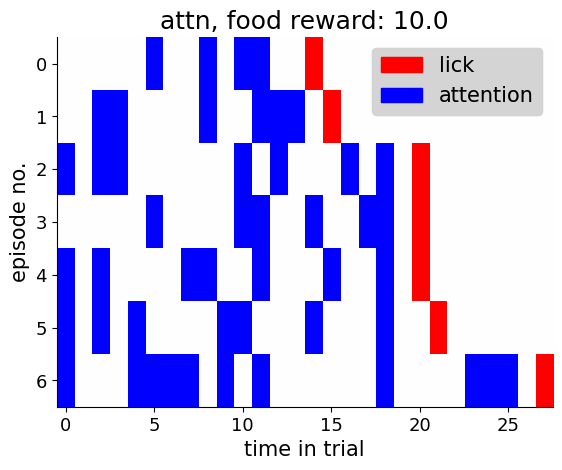

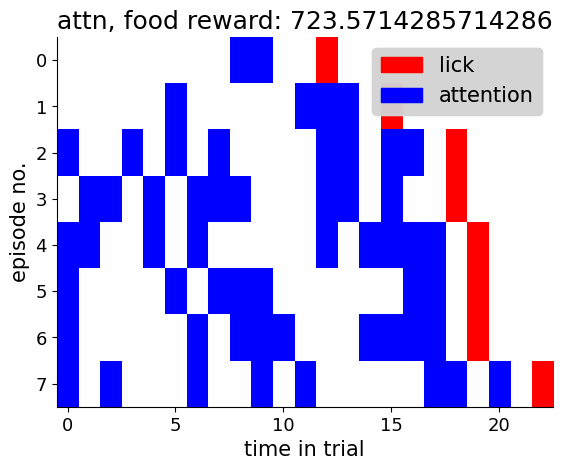

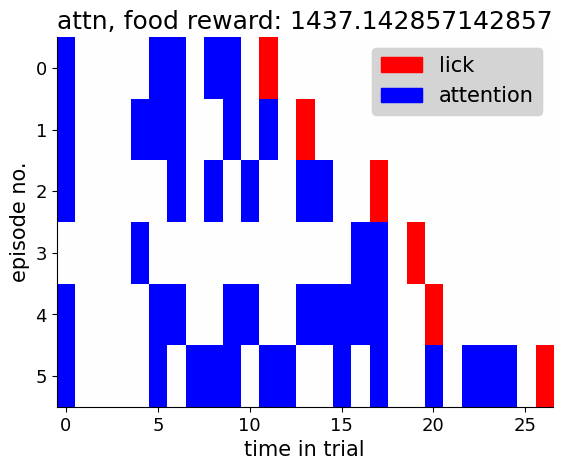

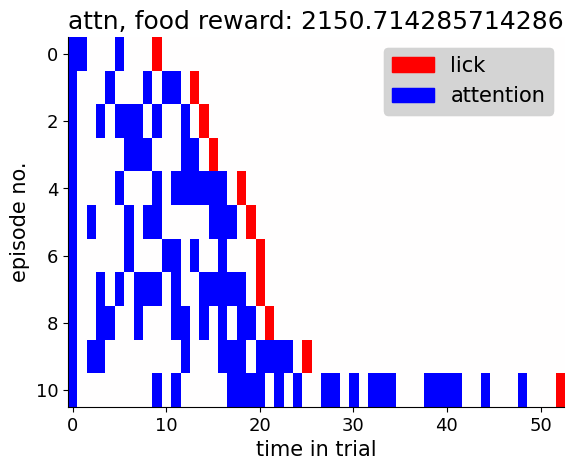

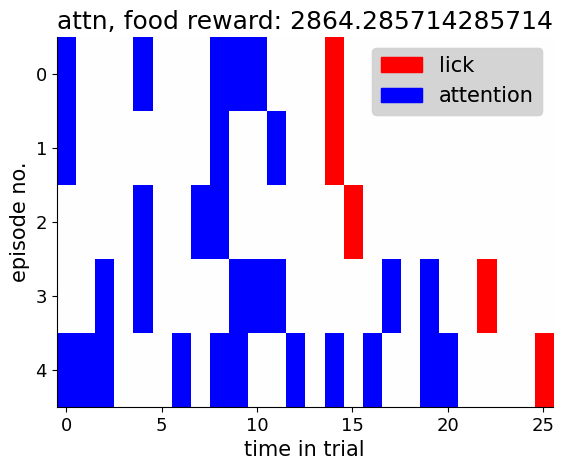

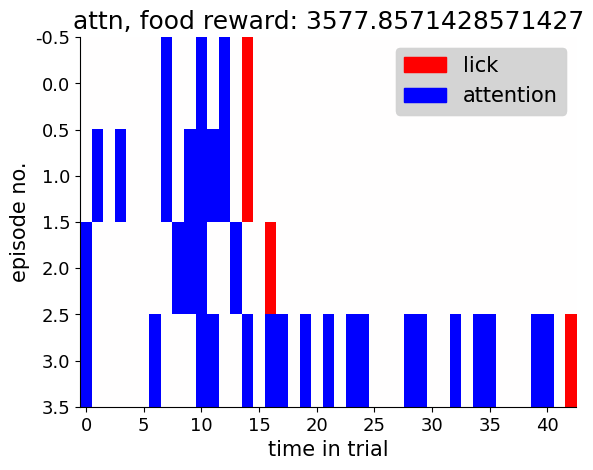

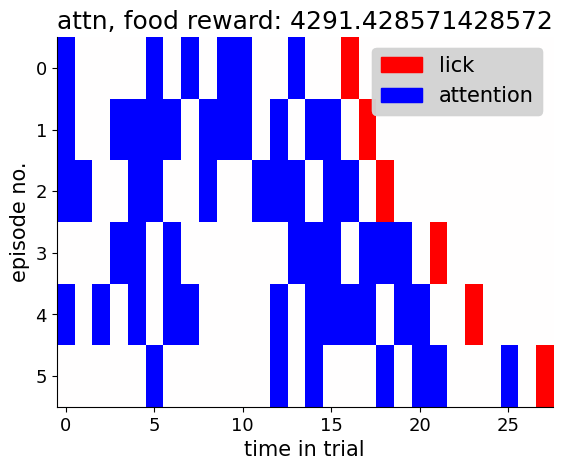

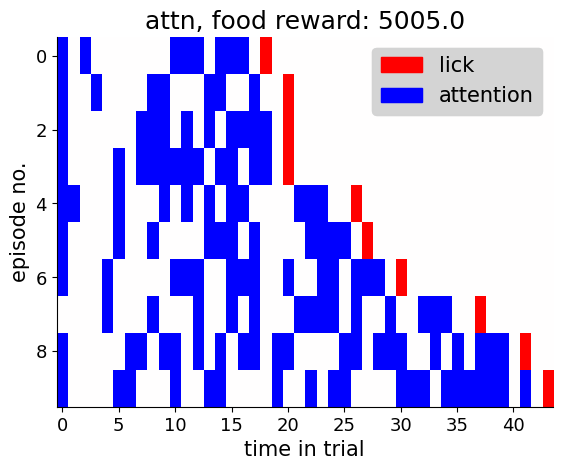

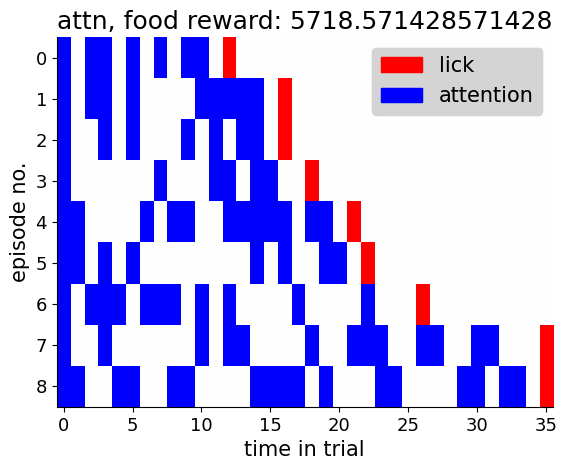

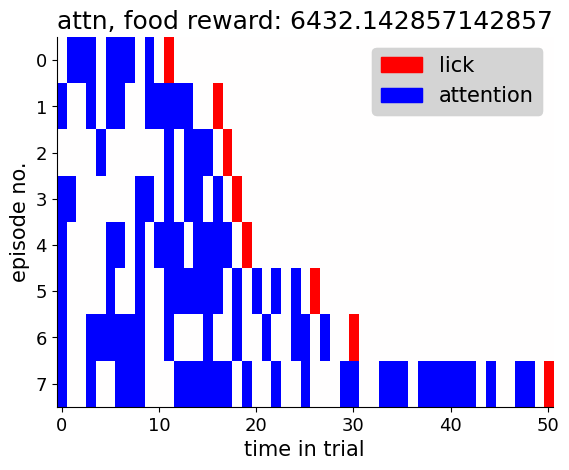

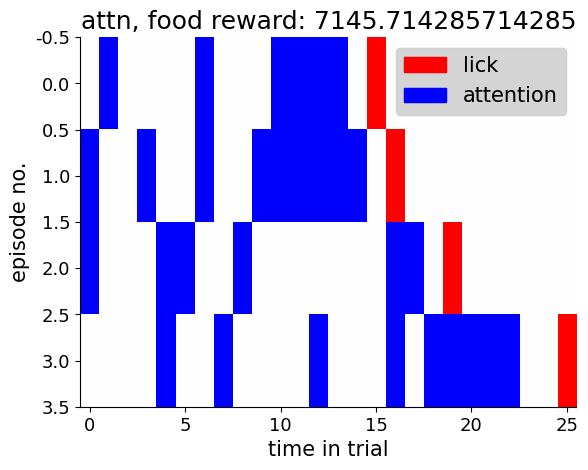

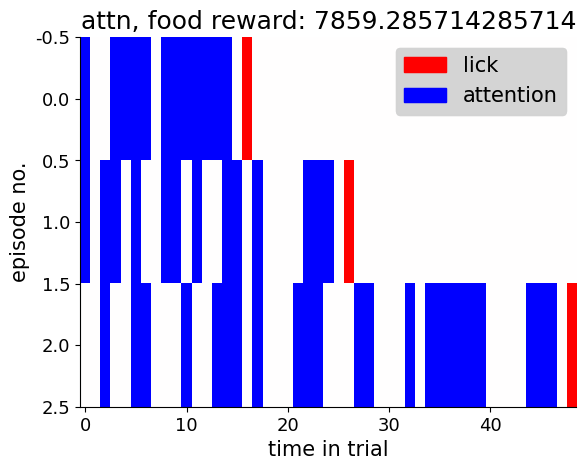

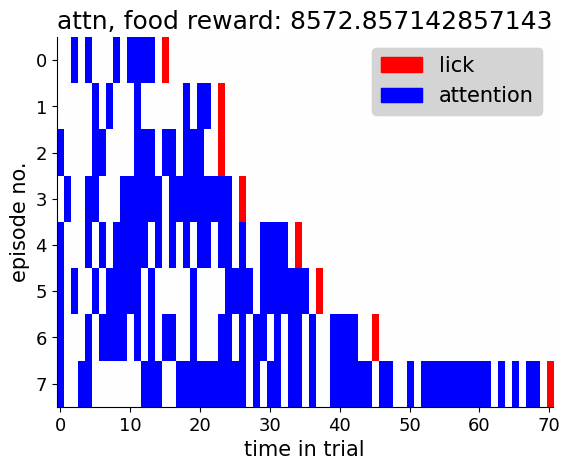

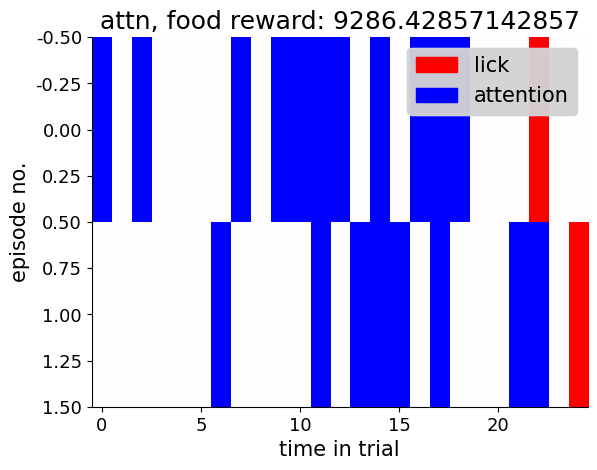

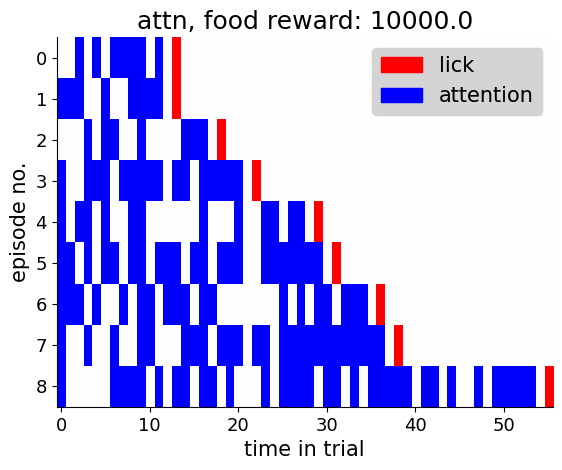

In [ ]:
# heatmap trial indicator (att and lick)
plot_no_episodes=10000

for food_reward_idx in (all_reward_res.keys()):
    attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=all_reward_res[food_reward_idx]
    sortind=np.argsort(trial_len[:plot_no_episodes])

    grid = np.zeros((plot_no_episodes, max(trial_len)+2))

    # att
    plot_data =att_time_list[:plot_no_episodes]
    for i, arr in enumerate(plot_data):
        grid[i, arr] = -1

    # lick
    plot_data =lick_time_list[:plot_no_episodes]
    for i, arr in enumerate(plot_data):
        if arr:
            grid[i, arr] = 1
    
    plt.figure()
    c=plt.imshow(grid[sortind], cmap='bwr', vmin=-1, vmax=1,
                    aspect='auto', interpolation='none')
    # plt.colorbar(c)
    plt.xlabel('time in trial')
    plt.ylabel('episode no.')
    plt.title(f'attn, food reward: {food_reward_list[food_reward_idx]}')

    # legend
    from matplotlib.patches import Patch

    # Create Patch objects for the custom legend
    red_patch = Patch(color='red', label='lick')
    blue_patch = Patch(color='blue', label='attention')

    # Create a new legend
    extra_legend = plt.legend(handles=[red_patch, blue_patch], loc='upper right', frameon=True)
    frame = extra_legend.get_frame()
    frame.set_color('lightgrey')

    # Add the new legend to the existing plot
    plt.gca().add_artist(extra_legend)
    quicksave(f'ep indicator {food_reward_idx}', modelname)
    plt.show()
